### **Installations and Imports**

In [1]:
import importlib.util
import subprocess
import sys
from importlib.metadata import version as pkg_version, PackageNotFoundError

def is_installed(import_name):
    return importlib.util.find_spec(import_name) is not None

# package_name_on_pip : import_name_in_python
required = {
    "unsloth": "unsloth",
    "unsloth_zoo": "unsloth_zoo",
    "trl": "trl",
    "bitsandbytes": "bitsandbytes",
    "sacrebleu": "sacrebleu",
    "evaluate": "evaluate",
    "packaging": "packaging",
}

missing = [
    pip_name
    for pip_name, import_name in required.items()
    if not is_installed(import_name)
]

print("Missing packages:", missing)

if missing:
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--no-cache-dir",
        *missing,
    ]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
else:
    print("All required extra packages are already installed.")

# Qwen3 needs recent transformers.
from packaging.version import parse as parse_version

def installed_version(package_name):
    try:
        return pkg_version(package_name)
    except PackageNotFoundError:
        return None

transformers_version = installed_version("transformers")
print("Current transformers:", transformers_version)

if transformers_version is None or parse_version(transformers_version) < parse_version("4.51.0"):
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "transformers>=4.51.0",
    ]
    print("Upgrading transformers for Qwen3 support:")
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
else:
    print("transformers version is OK for Qwen3.")

print("Minimal installation finished.")

Missing packages: ['unsloth', 'unsloth_zoo', 'trl', 'bitsandbytes', 'sacrebleu', 'evaluate']
Running: /usr/bin/python3 -m pip install -q --no-cache-dir unsloth unsloth_zoo trl bitsandbytes sacrebleu evaluate
Current transformers: 5.5.0
transformers version is OK for Qwen3.
Minimal installation finished.


In [2]:
# ============================================================
# Cell 1B — Verify environment
# ============================================================

import torch
import datasets
import transformers
import peft
import accelerate
import trl
import unsloth
import bitsandbytes
import sacrebleu

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: CUDA is not available.")
    print("Do not start Qwen/Unsloth fine-tuning on CPU.")
    print("Go to Runtime → Change runtime type → GPU.")

print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("trl:", trl.__version__)
print("sacrebleu:", sacrebleu.__version__)

print("Environment check finished.")

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:165: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
datasets: 4.3.0
transformers: 5.5.0
peft: 0.19.1
accelerate: 1.13.0
trl: 0.24.0
sacrebleu: 2.6.0
Environment check finished.


### **Paths and Configurations**

In [4]:
# ============================================================
# Cell 2 — Mount Google Drive and define paths
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/alexandria_qwen35_sft")
DATA_DIR    = PROJECT_DIR / "prepared_data"
RUNS_DIR    = PROJECT_DIR / "runs"
ADAPTER_DIR = PROJECT_DIR / "final_adapters"
PRED_DIR    = PROJECT_DIR / "predictions"

for p in [PROJECT_DIR, DATA_DIR, RUNS_DIR, ADAPTER_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("ADAPTER_DIR:", ADAPTER_DIR)
print("PRED_DIR:", PRED_DIR)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/alexandria_qwen35_sft
DATA_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/prepared_data
RUNS_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/runs
ADAPTER_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/final_adapters
PRED_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/predictions


In [7]:
# ============================================================
# Cell 3 — Experiment configuration
# Qwen3-4B BASE, NO few-shot, ALL group, r=16, 10 epochs
# Clean ablation against complete2shot all-r16
# ============================================================

import torch
import random
import numpy as np

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

MODEL_NAME = "Qwen/Qwen3-4B-Base"
LOAD_IN_4BIT = True

# ------------------------------------------------------------
# Dataset/config selection
# ------------------------------------------------------------

SELECTED_CONFIGS_MODE = "EG_ONLY"
MANUAL_CONFIGS = ["EG"]

MAX_CONTEXT_TURNS = 3
USE_PREVIOUS_ENGLISH_CONTEXT = True
USE_METADATA = True

# ------------------------------------------------------------
# Few-shot setup
# This ablation intentionally uses ZERO few-shot examples.
# ------------------------------------------------------------

USE_FEW_SHOTS = False
N_FEW_SHOTS = 0
MAX_FEW_SHOT_EXAMPLE_CHARS = None

# Keep same as complete2shot run for fair comparison.
MAX_SEQ_LENGTH = 2048

# ------------------------------------------------------------
# LoRA setup
# ------------------------------------------------------------

LORA_MODE = "all"
LORA_R = 16
LORA_ALPHA = 32

# ------------------------------------------------------------
# Training setup
# ------------------------------------------------------------

NUM_EPOCHS = 10

PER_DEVICE_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8

LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03

SAVE_STEPS = 100
EVAL_STEPS = 100
LOGGING_STEPS = 10

PACKING = False
SAVE_TOTAL_LIMIT = 50

# ------------------------------------------------------------
# Experiment naming
# ------------------------------------------------------------

if LORA_MODE == "attn":
    LORA_GROUP_NAME = "attn_group"
elif LORA_MODE == "mlp":
    LORA_GROUP_NAME = "fnn_group"
elif LORA_MODE == "all":
    LORA_GROUP_NAME = "all_group"
else:
    raise ValueError("LORA_MODE must be 'attn', 'mlp', or 'all'.")

EXPERIMENT_NAME = (
    f"qwen3_4b_alexandria_{SELECTED_CONFIGS_MODE.lower()}_"
    f"context{MAX_CONTEXT_TURNS}_noshot_{LORA_GROUP_NAME}_r{LORA_R}_10epochs_v1"
)

OUTPUT_DIR = RUNS_DIR / EXPERIMENT_NAME
FINAL_ADAPTER_PATH = ADAPTER_DIR / EXPERIMENT_NAME

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Experiment:", EXPERIMENT_NAME)
print("Few-shot enabled:", USE_FEW_SHOTS)
print("LoRA mode:", LORA_MODE)
print("LoRA r:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)
print("Max seq length:", MAX_SEQ_LENGTH)
print("Output dir:", OUTPUT_DIR)
print("Final adapter:", FINAL_ADAPTER_PATH)

Model: Qwen/Qwen3-4B-Base
Experiment: qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1
Few-shot enabled: False
LoRA mode: all
LoRA r: 16
LoRA alpha: 32
Max seq length: 2048
Output dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1
Final adapter: /content/drive/MyDrive/alexandria_qwen35_sft/final_adapters/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1


### **Dataset Preparation**

In [8]:
# ============================================================
# Cell 4 — List Alexandria configs and load selected configs
# ============================================================

from datasets import load_dataset, get_dataset_config_names
import pandas as pd

DATASET_NAME = "UBC-NLP/alexandria"

available_configs = get_dataset_config_names(DATASET_NAME)
print("Available Alexandria configs:")
print(available_configs)

if SELECTED_CONFIGS_MODE == "EG_ONLY":
    selected_configs = ["EG"] if "EG" in available_configs else [available_configs[0]]

elif SELECTED_CONFIGS_MODE == "ALL":
    selected_configs = available_configs

elif SELECTED_CONFIGS_MODE == "MANUAL":
    selected_configs = MANUAL_CONFIGS
    missing = [c for c in selected_configs if c not in available_configs]
    if missing:
        raise ValueError(f"These configs are not available: {missing}")

else:
    raise ValueError("SELECTED_CONFIGS_MODE must be EG_ONLY, ALL, or MANUAL.")

print("\nSelected configs:")
print(selected_configs)

loaded = {}

for cfg in selected_configs:
    print(f"\nLoading config: {cfg}")
    ds_train = load_dataset(DATASET_NAME, name=cfg, split="train")
    ds_test  = load_dataset(DATASET_NAME, name=cfg, split="test")

    loaded[cfg] = {
        "train": ds_train,
        "test": ds_test,
    }

    print("Train:", ds_train)
    print("Test:", ds_test)
    print("Example keys:", ds_train[0].keys())

Available Alexandria configs:
['EG', 'JO', 'LB', 'LY', 'MA', 'MR', 'OM', 'PS', 'SA', 'SD', 'SY', 'TN', 'YE']

Selected configs:
['EG']

Loading config: EG


EG/train-00000-of-00001.parquet:   0%|          | 0.00/496k [00:00<?, ?B/s]

EG/test-00000-of-00001.parquet:   0%|          | 0.00/196k [00:00<?, ?B/s]

EG/dev-00000-of-00001.parquet:   0%|          | 0.00/183k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/982 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/366 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/352 [00:00<?, ? examples/s]

Train: Dataset({
    features: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'],
    num_rows: 982
})
Test: Dataset({
    features: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'],
    num_rows: 366
})
Example keys: dict_keys(['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'])


In [9]:
# ============================================================
# Cell 5 — Inspect one raw example
# ============================================================

sample_cfg = selected_configs[0]
sample_row = loaded[sample_cfg]["train"][0]

print("Config:", sample_cfg)
print("Keys:", sample_row.keys())

print("\nEnglish conversation:")
print(sample_row["english_conversation"])

print("\nDialectal conversation:")
print(sample_row["dialectal_conversation"])

print("\nFull row:")
sample_row

Config: EG
Keys: dict_keys(['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'])

English conversation:
[{'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': "Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?", 'turn_order': 1}, {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': "Good morning to you. You heard correctly. My artichokes are the best you'll find. They are top-grade, perfect for export. Let me show you a sample.", 'turn_order': 2}, {'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': 'Excellent. Yes, please show me. I need them to be a specific size and completely free of blemishes.', 'turn_order': 3}, {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': "Don't you worry. You will be very satisfied. My reputatio

{'conv_id': 'B7-1-0-120',
 'country': 'EG',
 'domain': 'Agriculture and farming',
 'dialect': 'Egyptian Arabic (Cairene) Dialect',
 'participants': 'Wholesale Buyer, Wholesale Seller',
 'english_conversation': [{'direction': 'male -> female',
   'speaker': 'Wholesale Buyer',
   'text': "Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?",
   'turn_order': 1},
  {'direction': 'female -> male',
   'speaker': 'Wholesale Seller',
   'text': "Good morning to you. You heard correctly. My artichokes are the best you'll find. They are top-grade, perfect for export. Let me show you a sample.",
   'turn_order': 2},
  {'direction': 'male -> female',
   'speaker': 'Wholesale Buyer',
   'text': 'Excellent. Yes, please show me. I need them to be a specific size and completely free of blemishes.',
   'turn_order': 3},
  {'direction': 'female -> male',
   'speaker': 'Wholesale Seller',
   'text': "D

#### Helper functions for robust extraction

In [10]:
# ============================================================
# Cell 6 — Helper functions for robust extraction
# ============================================================

def safe_get(row, keys, default=""):
    for k in keys:
        if isinstance(row, dict) and k in row and row[k] is not None:
            return row[k]
    return default

def turn_text(turn):
    if isinstance(turn, dict):
        for k in ["text", "sentence", "utterance", "content", "value"]:
            if k in turn and turn[k] is not None:
                return str(turn[k]).strip()
        return str(turn).strip()
    return str(turn).strip()

def turn_field(turn, keys, default=""):
    if isinstance(turn, dict):
        for k in keys:
            if k in turn and turn[k] is not None:
                return str(turn[k]).strip()
    return default

def normalize_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return list(x)

def truncate_text(text, max_chars=1200):
    text = str(text)
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + " ..."

#### Flatten Alexandria conversations into SFT examples and Save

In [11]:
# ============================================================
# Cell 7 — Flatten Alexandria conversations
# ============================================================

def flatten_alexandria_split(ds, cfg_name, split_name, max_context_turns=3):
    records = []

    for conv_idx, row in enumerate(ds):
        english_conv = normalize_list(row["english_conversation"])
        dialect_conv = normalize_list(row["dialectal_conversation"])

        n = min(len(english_conv), len(dialect_conv))

        country = safe_get(row, ["country", "country_code"], cfg_name)
        dialect = safe_get(row, ["dialect", "dialect_label", "subdialect", "city", "variety"], "")
        domain = safe_get(row, ["domain", "topic"], "")
        persona = safe_get(row, ["persona", "roles", "speaker_roles"], "")
        conv_id = safe_get(row, ["conversation_id", "id", "dialogue_id"], f"{cfg_name}_{split_name}_{conv_idx}")

        for i in range(n):
            en_turn = english_conv[i]
            ar_turn = dialect_conv[i]

            source_text = turn_text(en_turn)
            target_text = turn_text(ar_turn)

            if not source_text or not target_text:
                continue

            prev_start = max(0, i - max_context_turns)
            prev_en_turns = english_conv[prev_start:i]

            previous_context = []
            for j, t in enumerate(prev_en_turns, start=prev_start):
                previous_context.append({
                    "turn_id": j,
                    "speaker": turn_field(t, ["speaker", "role", "speaker_role"], ""),
                    "direction": turn_field(t, ["direction", "gender_direction", "speaker_addressee_gender"], ""),
                    "text": turn_text(t),
                })

            records.append({
                "source_id": f"{cfg_name}_{split_name}_{conv_id}_{i}",
                "config": cfg_name,
                "split": split_name,
                "conversation_id": conv_id,
                "turn_id": i,

                "country": country,
                "dialect": dialect,
                "domain": domain,
                "persona": persona,

                "speaker": turn_field(en_turn, ["speaker", "role", "speaker_role"], ""),
                "gender_direction": turn_field(en_turn, ["direction", "gender_direction", "speaker_addressee_gender"], ""),

                "previous_english_turns": previous_context,
                "source_text": source_text,
                "target_arabic": target_text,
            })

    return records

train_records = []
eval_records = []

for cfg in selected_configs:
    train_records.extend(
        flatten_alexandria_split(
            loaded[cfg]["train"],
            cfg_name=cfg,
            split_name="train",
            max_context_turns=MAX_CONTEXT_TURNS,
        )
    )

    eval_records.extend(
        flatten_alexandria_split(
            loaded[cfg]["test"],
            cfg_name=cfg,
            split_name="test",
            max_context_turns=MAX_CONTEXT_TURNS,
        )
    )

train_df = pd.DataFrame(train_records)
eval_df = pd.DataFrame(eval_records)

print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)

print("\nTrain configs:")
print(train_df["config"].value_counts())

print("\nEval configs:")
print(eval_df["config"].value_counts())

display(train_df.head())

Train shape: (3108, 14)
Eval shape: (1118, 14)

Train configs:
config
EG    3108
Name: count, dtype: int64

Eval configs:
config
EG    1118
Name: count, dtype: int64


,source_id,config,split,conversation_id,turn_id,country,dialect,domain,persona,speaker,gender_direction,previous_english_turns,source_text,target_arabic
0,EG_train_EG_train_0_0,EG,train,EG_train_0,0,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Buyer,male -> female,[],Good morning. I'm looking to source 10 tons of...,صباح الخير، عايز عشرة طن من الخرشوف الكويس للت...
1,EG_train_EG_train_0_1,EG,train,EG_train_0,1,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Seller,female -> male,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...",Good morning to you. You heard correctly. My a...,صباح النور،سمعك مظبوط،الخرشوف بتاعي من أحسن ال...
2,EG_train_EG_train_0_2,EG,train,EG_train_0,2,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Buyer,male -> female,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...","Excellent. Yes, please show me. I need them to...",ممتاز، لو سمحتي وريني، عايزه بمقاس واحد ومافيه...
3,EG_train_EG_train_0_3,EG,train,EG_train_0,3,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Seller,female -> male,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...",Don't you worry. You will be very satisfied. M...,متخافش، هتنبسط جدا، سمعتي جاية من الحاجة الكويسة.
4,EG_train_EG_train_1_0,EG,train,EG_train_1,0,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Farmer,female -> female,[],I usually use the regular granular fertilizer....,أنا عادة بستخدم السماد العادي الحبيبات. ايه فا...


In [12]:
# ============================================================
# Cell 8 — Save prepared flattened data
# ============================================================

train_jsonl = DATA_DIR / f"alexandria_train_{SELECTED_CONFIGS_MODE.lower()}_context{MAX_CONTEXT_TURNS}.jsonl"
eval_jsonl  = DATA_DIR / f"alexandria_eval_{SELECTED_CONFIGS_MODE.lower()}_context{MAX_CONTEXT_TURNS}.jsonl"

train_df.to_json(train_jsonl, orient="records", lines=True, force_ascii=False)
eval_df.to_json(eval_jsonl, orient="records", lines=True, force_ascii=False)

print("Saved train:", train_jsonl)
print("Saved eval:", eval_jsonl)

Saved train: /content/drive/MyDrive/alexandria_qwen35_sft/prepared_data/alexandria_train_eg_only_context3.jsonl
Saved eval: /content/drive/MyDrive/alexandria_qwen35_sft/prepared_data/alexandria_eval_eg_only_context3.jsonl


### **Build prompt and chat messages**

In [14]:
# ============================================================
# Cell 9 — Build no-shot prompt for Qwen3-4B Base
# Completion-style SFT, no chat template
# ============================================================

from datasets import Dataset
import pandas as pd

def build_context(previous_turns):
    if not USE_PREVIOUS_ENGLISH_CONTEXT or not previous_turns:
        return "No previous context."

    lines = []

    for i, t in enumerate(previous_turns, start=1):
        speaker = str(t.get("speaker", "")).strip()
        text = str(t.get("text", "")).strip()

        if speaker:
            lines.append(f"{i}. {speaker}: {text}")
        else:
            lines.append(f"{i}. {text}")

    return "\n".join(lines) if lines else "No previous context."

def build_metadata_block(row):
    if not USE_METADATA:
        return "No metadata."

    fields = [
        ("Country/config", row.get("config", "")),
        ("Target dialect", row.get("dialect", "")),
        ("Domain", row.get("domain", "")),
        ("Persona/Roles", row.get("persona", "")),
        ("Current speaker", row.get("speaker", "")),
        ("Speaker-to-addressee gender direction", row.get("gender_direction", "")),
    ]

    lines = []

    for k, v in fields:
        v = str(v).strip()
        if v:
            lines.append(f"{k}: {v}")

    return "\n".join(lines) if lines else "No metadata."

def make_base_prompt(row):
    context = build_context(row["previous_english_turns"])
    metadata = build_metadata_block(row)

    return f"""### Instruction:
Translate the current English dialogue turn into the target dialectal Arabic variety.
Return only the Arabic translation.

### Metadata:
{metadata}

### Previous English dialogue context:
{context}

### Current English turn:
{row["source_text"]}

### Rules:
- Preserve the meaning exactly.
- Use the target local dialect, not Modern Standard Arabic unless it is natural in context.
- Preserve names, numbers, named entities, and technical terms when appropriate.
- Keep the tone appropriate for the speaker and domain.
- Do not add explanations, notes, labels, or metadata.

### Arabic translation:
"""

def row_to_prompt_and_target(row):
    prompt = make_base_prompt(row)
    target = str(row["target_arabic"]).strip()
    return prompt, target

train_df["prompt"] = train_df.apply(lambda row: row_to_prompt_and_target(row)[0], axis=1)
train_df["target"] = train_df.apply(lambda row: row_to_prompt_and_target(row)[1], axis=1)

eval_df["prompt"] = eval_df.apply(lambda row: row_to_prompt_and_target(row)[0], axis=1)
eval_df["target"] = eval_df.apply(lambda row: row_to_prompt_and_target(row)[1], axis=1)

train_dataset = Dataset.from_pandas(
    train_df[
        [
            "prompt",
            "target",
            "source_id",
            "config",
            "domain",
            "dialect",
            "source_text",
            "target_arabic",
        ]
    ],
    preserve_index=False,
)

eval_dataset = Dataset.from_pandas(
    eval_df[
        [
            "prompt",
            "target",
            "source_id",
            "config",
            "domain",
            "dialect",
            "source_text",
            "target_arabic",
        ]
    ],
    preserve_index=False,
)

print(train_dataset)
print(eval_dataset)

print("\nPrompt example:")
print(train_dataset[0]["prompt"])

print("\nTarget example:")
print(train_dataset[0]["target"])

Dataset({
    features: ['prompt', 'target', 'source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic'],
    num_rows: 3108
})
Dataset({
    features: ['prompt', 'target', 'source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic'],
    num_rows: 1118
})

Prompt example:
### Instruction:
Translate the current English dialogue turn into the target dialectal Arabic variety.
Return only the Arabic translation.

### Metadata:
Country/config: EG
Target dialect: Egyptian Arabic (Cairene) Dialect
Domain: Agriculture and farming
Current speaker: Wholesale Buyer
Speaker-to-addressee gender direction: male -> female

### Previous English dialogue context:
No previous context.

### Current English turn:
Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?

### Rules:
- Preserve the meaning exactly.
- Use the target local dialect, not Modern Standard Arabic unless 

### **Load Qwen3-4B with Unsloth**

In [15]:
# ============================================================
# UPDATED Cell 10 — Load Qwen3-4B with Unsloth
# Prefer FastLanguageModel for text-only SFT
# ============================================================

import torch

try:
    from unsloth import FastLanguageModel
    UnslothModel = FastLanguageModel
    print("Using unsloth.FastLanguageModel")
except Exception:
    from unsloth import FastModel
    UnslothModel = FastModel
    print("Using unsloth.FastModel fallback")

dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

model, tokenizer = UnslothModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = dtype,
    load_in_4bit = LOAD_IN_4BIT,
)

# If Unsloth returns a processor-like object, extract the real tokenizer if available.
if hasattr(tokenizer, "tokenizer"):
    print("Tokenizer object has internal tokenizer. Using tokenizer.tokenizer.")
    tokenizer = tokenizer.tokenizer

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)
print("dtype:", dtype)
print("load_in_4bit:", LOAD_IN_4BIT)
print("Tokenizer type:", type(tokenizer))
print("pad token:", tokenizer.pad_token)
print("eos token:", tokenizer.eos_token)

Using unsloth.FastLanguageModel
==((====))==  Unsloth 2026.6.1: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/qwen3-4b-base-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Loaded: Qwen/Qwen3-4B-Base
dtype: torch.float16
load_in_4bit: True
Tokenizer type: <class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
pad token: <|PAD_TOKEN|>
eos token: <|endoftext|>


### **Apply Chat Template**

In [16]:
# ============================================================
# Cell 11 — Build SFT text field
# Qwen3-4B Base, no chat template
# ============================================================

EOS = tokenizer.eos_token if tokenizer.eos_token is not None else ""

def build_sft_text(example):
    text = example["prompt"] + str(example["target"]).strip() + EOS
    return {"text": text}

remove_cols_train = [c for c in train_dataset.column_names if c in ["prompt", "target"]]
remove_cols_eval = [c for c in eval_dataset.column_names if c in ["prompt", "target"]]

train_dataset_text = train_dataset.map(
    build_sft_text,
    remove_columns=remove_cols_train,
)

eval_dataset_text = eval_dataset.map(
    build_sft_text,
    remove_columns=remove_cols_eval,
)

print(train_dataset_text)
print(eval_dataset_text)

print("\nFormatted SFT example:")
print(train_dataset_text[0]["text"])

# ------------------------------------------------------------
# Token length diagnostics
# ------------------------------------------------------------

def count_tokens(example):
    ids = tokenizer(
        example["text"],
        add_special_tokens=False,
        truncation=False,
    )["input_ids"]

    return {"n_tokens": len(ids)}

train_dataset_text = train_dataset_text.map(count_tokens, desc="Counting train tokens")
eval_dataset_text = eval_dataset_text.map(count_tokens, desc="Counting eval tokens")

train_lengths = train_dataset_text["n_tokens"]
eval_lengths = eval_dataset_text["n_tokens"]

def summarize_lengths(lengths, name):
    s = pd.Series(lengths)
    print(f"\n{name} token length summary:")
    print("count:", len(s))
    print("min:", int(s.min()))
    print("median:", int(s.median()))
    print("p90:", int(s.quantile(0.90)))
    print("p95:", int(s.quantile(0.95)))
    print("p99:", int(s.quantile(0.99)))
    print("max:", int(s.max()))

summarize_lengths(train_lengths, "Train")
summarize_lengths(eval_lengths, "Eval")

too_long_train = sum(x > MAX_SEQ_LENGTH for x in train_lengths)
too_long_eval = sum(x > MAX_SEQ_LENGTH for x in eval_lengths)

print("\nMAX_SEQ_LENGTH:", MAX_SEQ_LENGTH)
print("Train examples longer than MAX_SEQ_LENGTH:", too_long_train)
print("Eval examples longer than MAX_SEQ_LENGTH:", too_long_eval)

if too_long_train > 0 or too_long_eval > 0:
    print("\nWARNING: Some examples exceed MAX_SEQ_LENGTH.")
else:
    print("\nOK: MAX_SEQ_LENGTH is enough.")

Map:   0%|          | 0/3108 [00:00<?, ? examples/s]

Map:   0%|          | 0/1118 [00:00<?, ? examples/s]

Dataset({
    features: ['source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic', 'text'],
    num_rows: 3108
})
Dataset({
    features: ['source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic', 'text'],
    num_rows: 1118
})

Formatted SFT example:
### Instruction:
Translate the current English dialogue turn into the target dialectal Arabic variety.
Return only the Arabic translation.

### Metadata:
Country/config: EG
Target dialect: Egyptian Arabic (Cairene) Dialect
Domain: Agriculture and farming
Current speaker: Wholesale Buyer
Speaker-to-addressee gender direction: male -> female

### Previous English dialogue context:
No previous context.

### Current English turn:
Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?

### Rules:
- Preserve the meaning exactly.
- Use the target local dialect, not Modern Standard Arabic unless it is natural in 

Counting train tokens:   0%|          | 0/3108 [00:00<?, ? examples/s]

Counting eval tokens:   0%|          | 0/1118 [00:00<?, ? examples/s]


Train token length summary:
count: 3108
min: 164
median: 237
p90: 287
p95: 303
p99: 327
max: 376

Eval token length summary:
count: 1118
min: 162
median: 238
p90: 288
p95: 302
p99: 329
max: 357

MAX_SEQ_LENGTH: 2048
Train examples longer than MAX_SEQ_LENGTH: 0
Eval examples longer than MAX_SEQ_LENGTH: 0

OK: MAX_SEQ_LENGTH is enough.


#### **Configure LoRA target modules**

In [ ]:
# ============================================================
# Cell 12 — Configure LoRA
# Safe rerun: ALL group, r=16
# ============================================================

if LORA_MODE == "attn":
    TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]

elif LORA_MODE == "mlp":
    TARGET_MODULES = ["gate_proj", "up_proj", "down_proj"]

elif LORA_MODE == "all":
    TARGET_MODULES = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ]

else:
    raise ValueError("LORA_MODE must be 'attn', 'mlp', or 'all'.")

print("Target modules:", TARGET_MODULES)
print("LoRA r:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)

model = UnslothModel.get_peft_model(
    model,
    r = LORA_R,
    target_modules = TARGET_MODULES,
    lora_alpha = LORA_ALPHA,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = SEED,
    max_seq_length = MAX_SEQ_LENGTH,
)

model.print_trainable_parameters()

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
LoRA r: 16
LoRA alpha: 32


Unsloth 2026.6.1 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


#### Check for existing checkpoints

In [17]:
# ============================================================
# Cell 13 — Check for existing checkpoints
# ============================================================

from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = None

if OUTPUT_DIR.exists():
    last_checkpoint = get_last_checkpoint(str(OUTPUT_DIR))

if last_checkpoint:
    print("Found checkpoint:")
    print(last_checkpoint)
else:
    print("No checkpoint found. Training will start from scratch.")

Found checkpoint:
/content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1/checkpoint-2000


### **Build SFTTrainer**

In [ ]:
# ============================================================
# Cell 14 — Build SFTTrainer
# ============================================================

from trl import SFTTrainer, SFTConfig

sft_args = SFTConfig(
    output_dir = str(OUTPUT_DIR),

    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size = 1,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,

    learning_rate = LEARNING_RATE,
    warmup_ratio = WARMUP_RATIO,
    lr_scheduler_type = "cosine",

    optim = "adamw_8bit",
    weight_decay = 0.01,

    logging_steps = LOGGING_STEPS,

    eval_strategy = "steps",
    eval_steps = EVAL_STEPS,

    save_strategy = "steps",
    save_steps = SAVE_STEPS,
    save_total_limit = SAVE_TOTAL_LIMIT,

    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),

    seed = SEED,
    dataset_num_proc = 2,
    report_to = "none",

    packing = PACKING,
    dataset_text_field = "text",
    max_length = MAX_SEQ_LENGTH,
)

try:
    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = train_dataset_text,
        eval_dataset = eval_dataset_text,
        args = sft_args,
    )
except TypeError:
    trainer = SFTTrainer(
        model = model,
        processing_class = tokenizer,
        train_dataset = train_dataset_text,
        eval_dataset = eval_dataset_text,
        args = sft_args,
    )

print("Trainer ready.")
print("Output dir:", OUTPUT_DIR)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/3108 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1118 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Trainer ready.
Output dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1


#### Response-only training with manual markers

In [18]:
# ============================================================
# Cell 15 — Train on Arabic translation response only
# Manual completion-style masking for Qwen3-4B Base
# ============================================================

def safe_len(x):
    try:
        return len(x)
    except Exception:
        return None

print("Before response-only masking:")
print("trainer.train_dataset length:", safe_len(trainer.train_dataset))
print("trainer.eval_dataset length:", safe_len(trainer.eval_dataset))

if "trainer" not in globals():
    raise NameError("trainer is not defined. Run Cell 14 before Cell 15.")

if safe_len(trainer.train_dataset) == 0:
    raise ValueError("trainer.train_dataset is empty before masking.")

INSTRUCTION_MARKER = "### Instruction:"
RESPONSE_MARKER = "### Arabic translation:\n"

sample_text = train_dataset_text[0]["text"]

print("\nChecking manual SFT markers...")
print("Instruction marker found:", INSTRUCTION_MARKER in sample_text)
print("Response marker found:", RESPONSE_MARKER in sample_text)

if INSTRUCTION_MARKER not in sample_text or RESPONSE_MARKER not in sample_text:
    print("\nFormatted sample for debugging:")
    print(sample_text[:2000])
    raise ValueError("Manual SFT markers not found. Check Cell 9 and Cell 11.")

try:
    from unsloth.chat_templates import train_on_responses_only

    trainer = train_on_responses_only(
        trainer,
        instruction_part=INSTRUCTION_MARKER,
        response_part=RESPONSE_MARKER,
    )

    print("\nEnabled response-only training.")
    print("After response-only masking:")
    print("trainer.train_dataset length:", safe_len(trainer.train_dataset))
    print("trainer.eval_dataset length:", safe_len(trainer.eval_dataset))

    if safe_len(trainer.train_dataset) == 0:
        raise ValueError("Response-only masking produced an empty train dataset.")

except Exception as e:
    print("\nCould not enable response-only training safely.")
    print("Reason:", repr(e))
    raise

Before response-only masking:


NameError: name 'trainer' is not defined

### **Training**

In [ ]:
# ============================================================
# Cell 16 — Train or resume
# ============================================================

if last_checkpoint:
    print("Resuming from:", last_checkpoint)
    trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("Starting from scratch.")
    trainer_stats = trainer.train()

print("Training finished.")
print(trainer_stats)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting from scratch.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,108 | Num Epochs = 10 | Total steps = 3,890
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,1.907748,2.060021
200,1.778765,1.855445
300,1.563420,1.755375
400,1.332977,1.724139
500,1.198120,1.678046
600,1.222853,1.647130
700,1.254503,1.605091
800,0.714467,1.716581
900,0.699423,1.695783
1000,0.765689,1.692476


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

### **Save final LoRA adapter**

In [20]:
# ============================================================
# Cell 17 — Find, load, and save BEST checkpoint
# ============================================================

from pathlib import Path
import json
import torch

def find_best_checkpoint_from_logs(output_dir):
    output_dir = Path(output_dir)

    state_files = list(output_dir.rglob("trainer_state.json"))
    if not state_files:
        raise FileNotFoundError(f"No trainer_state.json found under: {output_dir}")

    best_state_file = None
    best_state = None
    max_global_step = -1

    for sf in state_files:
        try:
            state = json.loads(sf.read_text())
            global_step = int(state.get("global_step", -1))

            if global_step > max_global_step:
                max_global_step = global_step
                best_state_file = sf
                best_state = state
        except Exception:
            continue

    if best_state is None:
        raise RuntimeError("Could not read any valid trainer_state.json")

    # Prefer official best_model_checkpoint if available
    official_best = best_state.get("best_model_checkpoint", None)
    official_metric = best_state.get("best_metric", None)

    if official_best is not None:
        official_best_path = Path(official_best)

        if not official_best_path.exists():
            official_best_path = output_dir / official_best_path.name

        if official_best_path.exists():
            best_step = int(official_best_path.name.replace("checkpoint-", ""))
            return official_best_path, best_step, official_metric, None, best_state_file

    # Fallback: infer best checkpoint manually from eval_loss logs
    eval_rows = []

    for item in best_state.get("log_history", []):
        if "eval_loss" in item and "step" in item:
            eval_rows.append({
                "step": int(item["step"]),
                "eval_loss": float(item["eval_loss"]),
                "epoch": item.get("epoch", None),
            })

    if not eval_rows:
        raise RuntimeError("No eval_loss records found in trainer_state.json")

    best_row = min(eval_rows, key=lambda x: x["eval_loss"])

    best_step = best_row["step"]
    best_eval_loss = best_row["eval_loss"]
    best_epoch = best_row["epoch"]

    best_checkpoint_path = output_dir / f"checkpoint-{best_step}"

    if not best_checkpoint_path.exists():
        existing = sorted([p.name for p in output_dir.glob("checkpoint-*")])
        raise FileNotFoundError(
            f"Best checkpoint is missing: {best_checkpoint_path}\n"
            f"Best step from logs = {best_step}, eval_loss = {best_eval_loss}\n"
            f"Existing checkpoints: {existing}\n"
            f"Rerun with SAVE_TOTAL_LIMIT high enough."
        )

    return best_checkpoint_path, best_step, best_eval_loss, best_epoch, best_state_file


BEST_CHECKPOINT_PATH, BEST_STEP, BEST_EVAL_LOSS, BEST_EPOCH, BEST_STATE_FILE = find_best_checkpoint_from_logs(OUTPUT_DIR)

print("Best checkpoint:")
print("  path:", BEST_CHECKPOINT_PATH)
print("  step:", BEST_STEP)
print("  epoch:", BEST_EPOCH)
print("  eval_loss:", BEST_EVAL_LOSS)
print("  trainer_state:", BEST_STATE_FILE)

# ------------------------------------------------------------
# Load best checkpoint into the current trainer/model
# ------------------------------------------------------------

print("\nLoading best checkpoint into model...")

try:
    trainer._load_from_checkpoint(str(BEST_CHECKPOINT_PATH), model=trainer.model)
    model = trainer.model
    print("Loaded best checkpoint using trainer._load_from_checkpoint().")

except Exception as e:
    print("trainer._load_from_checkpoint failed:")
    print(repr(e))
    print("Trying PEFT fallback load...")

    from peft import PeftModel

    base_model, tokenizer = UnslothModel.from_pretrained(
        model_name = MODEL_NAME,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype = dtype,
        load_in_4bit = LOAD_IN_4BIT,
    )

    if hasattr(tokenizer, "tokenizer"):
        tokenizer = tokenizer.tokenizer

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = PeftModel.from_pretrained(base_model, str(BEST_CHECKPOINT_PATH))
    trainer.model = model

    print("Loaded best checkpoint using PEFT fallback.")

# ------------------------------------------------------------
# Save best adapter separately
# ------------------------------------------------------------

BEST_ADAPTER_PATH = ADAPTER_DIR / f"{EXPERIMENT_NAME}_best_step{BEST_STEP}"
BEST_ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

model.save_pretrained(str(BEST_ADAPTER_PATH))
tokenizer.save_pretrained(str(BEST_ADAPTER_PATH))

print("\nSaved BEST adapter to:")
print(BEST_ADAPTER_PATH)

print("\nActive model for inference is now the BEST checkpoint.")
print("BEST_CHECKPOINT_PATH:", BEST_CHECKPOINT_PATH)
print("BEST_STEP:", BEST_STEP)
print("BEST_EVAL_LOSS:", BEST_EVAL_LOSS)

Best checkpoint:
  path: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1/checkpoint-700
  step: 700
  epoch: 1.8005148005148004
  eval_loss: 1.6050914525985718
  trainer_state: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1/checkpoint-2000/trainer_state.json

Loading best checkpoint into model...
trainer._load_from_checkpoint failed:
NameError("name 'trainer' is not defined")
Trying PEFT fallback load...
==((====))==  Unsloth 2026.6.1: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colore

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

unsloth/qwen3-4b-base-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


NameError: name 'trainer' is not defined

### **Quick Inference**

In [19]:
# ============================================================
# Cell 18 — Quick inference
# Qwen3-4B Base, no-shot completion prompt
# Uses BEST checkpoint loaded in Cell 17
# ============================================================

import torch

if "BEST_CHECKPOINT_PATH" not in globals():
    raise RuntimeError("Run Cell 17 first to load the best checkpoint.")

print("Inference will use BEST checkpoint:")
print("BEST_CHECKPOINT_PATH:", BEST_CHECKPOINT_PATH)
print("BEST_STEP:", BEST_STEP)
print("BEST_EVAL_LOSS:", BEST_EVAL_LOSS)

try:
    UnslothModel.for_inference(model)
except Exception as e:
    print("for_inference not available or not needed:", repr(e))

def clean_generated_answer(answer):
    answer = str(answer).strip()

    if "</think>" in answer:
        answer = answer.split("</think>")[-1].strip()

    bad_prefixes = [
        "Arabic:",
        "Translation:",
        "Arabic translation:",
        "### Arabic translation:",
        "الترجمة:",
        "الترجمة العربية:",
    ]

    for p in bad_prefixes:
        if answer.startswith(p):
            answer = answer[len(p):].strip()

    return answer.strip()

def generate_translation_from_row(row, max_new_tokens=120):
    prompt = make_base_prompt(row)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated_ids = outputs[0][input_len:]
    decoded_answer = tokenizer.decode(generated_ids, skip_special_tokens=True)

    answer = clean_generated_answer(decoded_answer)

    return answer, decoded_answer

sample = eval_df.sample(1, random_state=SEED).iloc[0].to_dict()

pred, raw = generate_translation_from_row(sample)

print("Country/config:", sample["config"])
print("Dialect:", sample["dialect"])
print("Domain:", sample["domain"])

print("\nEnglish:")
print(sample["source_text"])

print("\nReference Arabic:")
print(sample["target_arabic"])

print("\nPrediction:")
print(pred)

print("\nRaw decoded:")
print(raw)

RuntimeError: Run Cell 17 first to load the best checkpoint.

In [ ]:
# ============================================================
# Audit Cell — Check whether prediction CSV matches current checkpoint
# Run after Cell 17 and before Cell 19 / metrics
# ============================================================

from pathlib import Path
import pandas as pd

eval_tag = f"best_step{BEST_STEP}"
pred_path = PRED_DIR / f"full_eval_predictions_{EXPERIMENT_NAME}_{eval_tag}.csv"

print("Expected prediction path:")
print(pred_path)

print("\nCurrent loaded best checkpoint:")
print(BEST_CHECKPOINT_PATH)

print("\nCurrent best step:", BEST_STEP)
print("Current best eval loss:", BEST_EVAL_LOSS)

if not pred_path.exists():
    print("\nNo prediction file exists yet. Fresh generation is required.")
else:
    pred_df_audit = pd.read_csv(pred_path)

    print("\nPrediction file exists.")
    print("Rows:", len(pred_df_audit))

    if "model_checkpoint" in pred_df_audit.columns:
        checkpoints = pred_df_audit["model_checkpoint"].dropna().astype(str).unique()
        print("\nCheckpoints recorded in prediction file:")
        for ckpt in checkpoints[:10]:
            print("-", ckpt)

        if len(checkpoints) == 1 and checkpoints[0] == str(BEST_CHECKPOINT_PATH):
            print("\nOK: Prediction file checkpoint matches current BEST_CHECKPOINT_PATH.")
        else:
            print("\nWARNING: Prediction file checkpoint does NOT exactly match current BEST_CHECKPOINT_PATH.")
            print("You should regenerate predictions with OVERWRITE_EXISTING=True.")
    else:
        print("\nWARNING: prediction file has no model_checkpoint column.")
        print("You cannot verify whether it matches the current checkpoint.")
        print("Regenerate predictions with OVERWRITE_EXISTING=True.")

    if "best_step" in pred_df_audit.columns:
        steps = pred_df_audit["best_step"].dropna().unique()
        print("\nBest steps recorded in prediction file:", steps)

        if len(steps) == 1 and int(steps[0]) == int(BEST_STEP):
            print("OK: Prediction best_step matches current BEST_STEP.")
        else:
            print("WARNING: Prediction best_step does not match current BEST_STEP.")
            print("Regenerate predictions with OVERWRITE_EXISTING=True.")
    else:
        print("\nWARNING: prediction file has no best_step column.")

Expected prediction path:
/content/drive/MyDrive/alexandria_qwen35_sft/predictions/full_eval_predictions_qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1_best_step700.csv

Current loaded best checkpoint:
/content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1/checkpoint-700

Current best step: 700
Current best eval loss: 1.6050914525985718

No prediction file exists yet. Fresh generation is required.


### Generate predictions for all eval set

In [ ]:
# ============================================================
# Cell 19 — Generate predictions on FULL eval/test set
# Uses BEST checkpoint loaded in Cell 17
# FORCE RE-PREDICTION VERSION
# ============================================================

from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
import time
import shutil

if "BEST_CHECKPOINT_PATH" not in globals():
    raise RuntimeError("Run Cell 17 first. The best checkpoint is not loaded.")

if "generate_translation_from_row" not in globals():
    raise RuntimeError("Run the generation-function cell before Cell 19.")

# None = full eval/test set
EVAL_LIMIT = None

SAVE_EVERY = 50
STORE_RAW_OUTPUT = False

# ------------------------------------------------------------
# IMPORTANT:
# True means regenerate predictions from zero even if CSV exists.
# Use True after retraining or changing prompt/generation/checkpoint.
# ------------------------------------------------------------

OVERWRITE_EXISTING = False
BACKUP_BEFORE_OVERWRITE = True

eval_tag = f"best_step{BEST_STEP}"

pred_path = PRED_DIR / f"full_eval_predictions_{EXPERIMENT_NAME}_{eval_tag}.csv"

print("Experiment:", EXPERIMENT_NAME)
print("Using BEST checkpoint:", BEST_CHECKPOINT_PATH)
print("Best step:", BEST_STEP)
print("Best eval_loss:", BEST_EVAL_LOSS)
print("Saving predictions to:", pred_path)
print("OVERWRITE_EXISTING:", OVERWRITE_EXISTING)

full_eval_df = eval_df.reset_index(drop=True).copy()

if EVAL_LIMIT is not None:
    full_eval_df = full_eval_df.iloc[:EVAL_LIMIT].copy()

expected_n = len(full_eval_df)

print("Total eval/test examples to evaluate:", expected_n)

# ------------------------------------------------------------
# Start fresh or resume
# ------------------------------------------------------------

if pred_path.exists() and OVERWRITE_EXISTING:
    if BACKUP_BEFORE_OVERWRITE:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        backup_path = pred_path.with_suffix(f".backup_{timestamp}.csv")
        shutil.copy2(pred_path, backup_path)
        print("Existing prediction file backed up to:", backup_path)

    pred_rows = []
    done_ids = set()
    print("FORCING fresh prediction generation from scratch.")

elif pred_path.exists() and not OVERWRITE_EXISTING:
    existing_df = pd.read_csv(pred_path)

    if "source_id" in existing_df.columns:
        existing_df["source_id"] = existing_df["source_id"].astype(str)

        expected_ids = set(full_eval_df["source_id"].astype(str).tolist())
        existing_df = existing_df[existing_df["source_id"].isin(expected_ids)].copy()
        existing_df = existing_df.drop_duplicates(subset=["source_id"], keep="first")

        pred_rows = existing_df.to_dict("records")
        done_ids = set(existing_df["source_id"].astype(str).tolist())

        print(f"Resuming from existing file: {len(done_ids)} examples already done.")

    else:
        print("Existing file has no source_id column. Starting from scratch.")
        pred_rows = []
        done_ids = set()

else:
    pred_rows = []
    done_ids = set()
    print("No existing prediction file. Starting from scratch.")

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

start_time = time.time()

for _, row in tqdm(full_eval_df.iterrows(), total=len(full_eval_df)):
    row_dict = row.to_dict()
    source_id = str(row_dict["source_id"])

    if source_id in done_ids:
        continue

    try:
        pred, raw = generate_translation_from_row(row_dict)

        out_row = {
            "source_id": row_dict["source_id"],
            "config": row_dict.get("config", ""),
            "dialect": row_dict.get("dialect", ""),
            "domain": row_dict.get("domain", ""),
            "source_text": row_dict["source_text"],
            "reference_arabic": row_dict["target_arabic"],
            "prediction": pred,
            "model_checkpoint": str(BEST_CHECKPOINT_PATH),
            "best_step": BEST_STEP,
            "best_eval_loss": BEST_EVAL_LOSS,
            "experiment_name": EXPERIMENT_NAME,
            "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        }

        if STORE_RAW_OUTPUT:
            out_row["raw_output"] = raw

    except Exception as e:
        out_row = {
            "source_id": row_dict.get("source_id", ""),
            "config": row_dict.get("config", ""),
            "dialect": row_dict.get("dialect", ""),
            "domain": row_dict.get("domain", ""),
            "source_text": row_dict.get("source_text", ""),
            "reference_arabic": row_dict.get("target_arabic", ""),
            "prediction": "",
            "generation_error": repr(e),
            "model_checkpoint": str(BEST_CHECKPOINT_PATH),
            "best_step": BEST_STEP,
            "best_eval_loss": BEST_EVAL_LOSS,
            "experiment_name": EXPERIMENT_NAME,
            "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        }

    pred_rows.append(out_row)
    done_ids.add(source_id)

    if len(pred_rows) % SAVE_EVERY == 0:
        tmp_df = pd.DataFrame(pred_rows)
        tmp_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
        print(f"Saved partial predictions: {len(tmp_df)} rows")

# ------------------------------------------------------------
# Final save
# ------------------------------------------------------------

pred_df = pd.DataFrame(pred_rows)

order_df = full_eval_df[["source_id"]].copy()
order_df["source_id"] = order_df["source_id"].astype(str)
order_df["eval_order"] = range(len(order_df))

pred_df["source_id"] = pred_df["source_id"].astype(str)
pred_df = pred_df.merge(order_df, on="source_id", how="left")
pred_df = pred_df.sort_values("eval_order").drop(columns=["eval_order"])
pred_df = pred_df.reset_index(drop=True)

pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

elapsed = time.time() - start_time

expected_ids = set(full_eval_df["source_id"].astype(str).tolist())
actual_ids = set(pred_df["source_id"].astype(str).tolist())

missing_ids = expected_ids - actual_ids
extra_ids = actual_ids - expected_ids

print("\nDone.")
print("Saved predictions to:", pred_path)
print("Total rows saved:", len(pred_df))
print("Expected eval/test rows:", expected_n)
print(f"Elapsed time: {elapsed / 60:.2f} minutes")

if missing_ids:
    raise RuntimeError(f"Prediction file is incomplete. Missing {len(missing_ids)} eval examples.")

if extra_ids:
    print(f"Warning: prediction file has {len(extra_ids)} extra source_ids not in current eval_df.")

if len(pred_df) == expected_n:
    print("Full eval/test set was evaluated successfully.")
else:
    print("Warning: row count differs from expected eval size.")

display(pred_df.head())

Experiment: qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1
Using BEST checkpoint: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1/checkpoint-700
Best step: 700
Best eval_loss: 1.6050914525985718
Saving predictions to: /content/drive/MyDrive/alexandria_qwen35_sft/predictions/full_eval_predictions_qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1_best_step700.csv
OVERWRITE_EXISTING: True
Total eval/test examples to evaluate: 1118
No existing prediction file. Starting from scratch.


  0%|          | 0/1118 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `tran

Saved partial predictions: 50 rows


Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Saved partial predictions: 1100 rows


Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene


Done.
Saved predictions to: /content/drive/MyDrive/alexandria_qwen35_sft/predictions/full_eval_predictions_qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1_best_step700.csv
Total rows saved: 1118
Expected eval/test rows: 1118
Elapsed time: 56.66 minutes
Full eval/test set was evaluated successfully.


,source_id,config,dialect,domain,source_text,reference_arabic,prediction,model_checkpoint,best_step,best_eval_loss,experiment_name,generated_at
0,EG_test_EG_test_0_0,EG,Egyptian Arabic (Cairene) Dialect,Commerce and transactions,"I would like one order of kunafa, please.",عايز واحد كنافة لو سمحت.,عايز طلب كونفا، لو سمحت.,/content/drive/MyDrive/alexandria_qwen35_sft/r...,700,1.605091,qwen3_4b_alexandria_eg_only_context3_noshot_al...,2026-06-04 02:59:25
1,EG_test_EG_test_0_1,EG,Egyptian Arabic (Cairene) Dialect,Commerce and transactions,Certainly. Would you like that with cheese or ...,أكيد. تحبها بالجبنة ولا بالقشطة؟,طبعا، تحبها بالجبن ولا بالكريمة؟,/content/drive/MyDrive/alexandria_qwen35_sft/r...,700,1.605091,qwen3_4b_alexandria_eg_only_context3_noshot_al...,2026-06-04 02:59:26
2,EG_test_EG_test_0_2,EG,Egyptian Arabic (Cairene) Dialect,Commerce and transactions,"With cream, please.",بالقشطة، لو سمحت.,مع كريم لو سمحت,/content/drive/MyDrive/alexandria_qwen35_sft/r...,700,1.605091,qwen3_4b_alexandria_eg_only_context3_noshot_al...,2026-06-04 02:59:27
3,EG_test_EG_test_1_0,EG,Egyptian Arabic (Cairene) Dialect,Commerce and transactions,"Pardon me, I believe the meat is overcooked. I...",لو سمحت، أعتقد اللحمة مستوية زيادة. ناشفة جدا.,لو سمحت، أنا شكل اللحمة مطبوخة قوية أوي. صعبة ...,/content/drive/MyDrive/alexandria_qwen35_sft/r...,700,1.605091,qwen3_4b_alexandria_eg_only_context3_noshot_al...,2026-06-04 02:59:29
4,EG_test_EG_test_1_1,EG,Egyptian Arabic (Cairene) Dialect,Commerce and transactions,"I'm very sorry to hear that, sir. Would you li...",آسفه جدا يا فندم. تحب أخلي الشيف يجهزلك واحدة ...,انا اسف جدا يا فندم، تحبي انا اخلي المطاعم يجه...,/content/drive/MyDrive/alexandria_qwen35_sft/r...,700,1.605091,qwen3_4b_alexandria_eg_only_context3_noshot_al...,2026-06-04 02:59:32


### **Compute BLEU and chrF**

In [ ]:
# ============================================================
# Cell 20 — Compute BLEU, chrF and chrF++ on FULL eval/test predictions
# Uses predictions from BEST checkpoint
# ============================================================

import pandas as pd
import json
from pathlib import Path

try:
    import sacrebleu
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"])
    import sacrebleu

if "BEST_STEP" not in globals():
    raise RuntimeError("BEST_STEP is not defined. Run Cell 17 first.")

eval_tag = f"best_step{BEST_STEP}"

pred_path = PRED_DIR / f"full_eval_predictions_{EXPERIMENT_NAME}_{eval_tag}.csv"
metrics_path = PRED_DIR / f"full_eval_metrics_{EXPERIMENT_NAME}_{eval_tag}.json"

print("Experiment:", EXPERIMENT_NAME)
print("Best checkpoint:", BEST_CHECKPOINT_PATH)
print("Best step:", BEST_STEP)
print("Prediction file:", pred_path)
print("Metrics file:", metrics_path)

if not pred_path.exists():
    raise FileNotFoundError(f"Prediction file not found: {pred_path}")

pred_df = pd.read_csv(pred_path)

required_cols = {"source_id", "prediction", "reference_arabic"}
missing = required_cols - set(pred_df.columns)

if missing:
    raise ValueError(f"Missing required columns in prediction file: {missing}")

pred_df["source_id"] = pred_df["source_id"].astype(str)
pred_df["prediction"] = pred_df["prediction"].fillna("").astype(str)
pred_df["reference_arabic"] = pred_df["reference_arabic"].fillna("").astype(str)

expected_eval_df = eval_df.reset_index(drop=True).copy()
expected_eval_df["source_id"] = expected_eval_df["source_id"].astype(str)

expected_ids = set(expected_eval_df["source_id"].tolist())
actual_ids = set(pred_df["source_id"].tolist())

missing_ids = expected_ids - actual_ids
extra_ids = actual_ids - expected_ids

print("\n==============================")
print("Full Eval/Test Coverage Check")
print("==============================")
print("Expected eval/test examples:", len(expected_eval_df))
print("Prediction rows:", len(pred_df))
print("Unique prediction source_ids:", len(actual_ids))

if missing_ids:
    raise RuntimeError(
        f"Prediction file is NOT full eval/test. "
        f"Missing {len(missing_ids)} examples. "
        f"Run Cell 19 again to finish generation."
    )

if extra_ids:
    print(f"Warning: prediction file has {len(extra_ids)} extra source_ids not in current eval_df.")

print("Full eval/test coverage confirmed.")

order_df = expected_eval_df[["source_id"]].copy()
pred_df_ordered = order_df.merge(pred_df, on="source_id", how="left")

preds = pred_df_ordered["prediction"].fillna("").astype(str).tolist()
refs = pred_df_ordered["reference_arabic"].fillna("").astype(str).tolist()

bleu = sacrebleu.corpus_bleu(preds, [refs])
chrf = sacrebleu.corpus_chrf(preds, [refs])
chrfpp = sacrebleu.corpus_chrf(preds, [refs], word_order=2)

metrics = {
    "experiment": EXPERIMENT_NAME,
    "checkpoint": str(BEST_CHECKPOINT_PATH),
    "best_step": int(BEST_STEP),
    "best_eval_loss": float(BEST_EVAL_LOSS),
    "num_examples": len(pred_df_ordered),
    "BLEU": bleu.score,
    "chrF": chrf.score,
    "chrF++": chrfpp.score,
    "prediction_file": str(pred_path),
}

print("\n==============================")
print("Full Eval/Test Metrics from BEST checkpoint")
print("==============================")
print(f"Examples: {len(pred_df_ordered)}")
print(f"BLEU:     {bleu.score:.4f}")
print(f"chrF:     {chrf.score:.4f}")
print(f"chrF++:   {chrfpp.score:.4f}")

def compute_group_metrics(df, group_col):
    rows = []

    if group_col not in df.columns:
        return pd.DataFrame(rows)

    for group_value in sorted(df[group_col].dropna().unique()):
        tmp = df[df[group_col] == group_value]

        if len(tmp) == 0:
            continue

        group_preds = tmp["prediction"].fillna("").astype(str).tolist()
        group_refs = tmp["reference_arabic"].fillna("").astype(str).tolist()

        rows.append({
            group_col: group_value,
            "num_examples": len(tmp),
            "BLEU": sacrebleu.corpus_bleu(group_preds, [group_refs]).score,
            "chrF": sacrebleu.corpus_chrf(group_preds, [group_refs]).score,
            "chrF++": sacrebleu.corpus_chrf(group_preds, [group_refs], word_order=2).score,
        })

    return pd.DataFrame(rows)

per_config_df = compute_group_metrics(pred_df_ordered, "config")
per_dialect_df = compute_group_metrics(pred_df_ordered, "dialect")
per_domain_df = compute_group_metrics(pred_df_ordered, "domain")

if len(per_config_df):
    print("\n==============================")
    print("Per-config Metrics")
    print("==============================")
    display(per_config_df)
    metrics["per_config"] = per_config_df.to_dict("records")

if len(per_dialect_df):
    print("\n==============================")
    print("Per-dialect Metrics")
    print("==============================")
    display(per_dialect_df)
    metrics["per_dialect"] = per_dialect_df.to_dict("records")

if len(per_domain_df):
    print("\n==============================")
    print("Per-domain Metrics")
    print("==============================")
    display(per_domain_df)
    metrics["per_domain"] = per_domain_df.to_dict("records")

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("\nSaved metrics to:")
print(metrics_path)

display(pred_df_ordered[["source_text", "reference_arabic", "prediction"]].head(10))

Experiment: qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1
Best checkpoint: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1/checkpoint-700
Best step: 700
Prediction file: /content/drive/MyDrive/alexandria_qwen35_sft/predictions/full_eval_predictions_qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1_best_step700.csv
Metrics file: /content/drive/MyDrive/alexandria_qwen35_sft/predictions/full_eval_metrics_qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1_best_step700.json

Full Eval/Test Coverage Check
Expected eval/test examples: 1118
Prediction rows: 1118
Unique prediction source_ids: 1118
Full eval/test coverage confirmed.

Full Eval/Test Metrics from BEST checkpoint
Examples: 1118
BLEU:     9.8258
chrF:     37.8942

Per-config Metrics


,config,num_examples,BLEU,chrF
0,EG,1118,9.825838,37.89418



Per-dialect Metrics


,dialect,num_examples,BLEU,chrF
0,Egyptian Arabic (Cairene) Dialect,1118,9.825838,37.89418



Per-domain Metrics


,domain,num_examples,BLEU,chrF
0,Agriculture and farming,100,9.803367,37.734629
1,Commerce and transactions,103,9.515211,38.065239
2,Construction and real estate,102,7.529399,36.562590
3,Education and academia,102,11.097642,37.276962
4,Energy and resources,103,8.971604,37.972709
5,Everyday and social,103,8.757464,35.276652
6,Healthcare and medical,102,15.225392,39.976002
7,Legal and financial,103,7.452028,39.937116
8,Logistics and transportation,100,9.538932,39.302017
9,Professional and workplace,100,9.111433,38.181707



Saved metrics to:
/content/drive/MyDrive/alexandria_qwen35_sft/predictions/full_eval_metrics_qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1_best_step700.json


,source_text,reference_arabic,prediction
0,"I would like one order of kunafa, please.",عايز واحد كنافة لو سمحت.,عايز طلب كونفا، لو سمحت.
1,Certainly. Would you like that with cheese or ...,أكيد. تحبها بالجبنة ولا بالقشطة؟,طبعا، تحبها بالجبن ولا بالكريمة؟
2,"With cream, please.",بالقشطة، لو سمحت.,مع كريم لو سمحت
3,"Pardon me, I believe the meat is overcooked. I...",لو سمحت، أعتقد اللحمة مستوية زيادة. ناشفة جدا.,لو سمحت، أنا شكل اللحمة مطبوخة قوية أوي. صعبة ...
4,"I'm very sorry to hear that, sir. Would you li...",آسفه جدا يا فندم. تحب أخلي الشيف يجهزلك واحدة ...,انا اسف جدا يا فندم، تحبي انا اخلي المطاعم يجه...
5,"Yes, please. Thank you.",أيوه لو سمحتي. شكرا.,ايوة لو سمحت، شكرا
6,"Honestly, the driver was rude and the car was ...",بصراحة، السواق كان بجح و العربيه ماكانتش نضيفه...,بصراحة السواق كان عدواني والعربيه مش نضيفة. كا...
7,I truly apologize that we failed to provide yo...,أنا حقيقي بعتذر ان احنا فشلنا اننا نقدملك خدمة...,انا انا اسف جدا اننا مشيتلك خدمة كويسة النهارد...
8,"Engineer, good morning. Before you run your ca...",صباح الخير يا هندسه. قبل ما تمد الكابلات في ال...,يا باشمهندس صباح الخير. قبل ما توصل الكابلات ف...
9,"Good thing you caught me, I was about to start...",كويس إنك لحقتني، أنا كنت هابدأ. هتحط خطوط المي...,حلو اني لقيتني، كنت هبدأ. هتعوض فين خطوط المية...


### **Error-analysis view by country/domain**

In [ ]:
# ============================================================
# Cell 21 — Qualitative error-analysis samples
# Uses FULL eval predictions from BEST checkpoint
# ============================================================

if "BEST_STEP" not in globals():
    raise RuntimeError("BEST_STEP is not defined. Run Cell 17 first.")

eval_tag = f"best_step{BEST_STEP}"

analysis_path = PRED_DIR / f"manual_analysis_{EXPERIMENT_NAME}_{eval_tag}.xlsx"

if "pred_df_ordered" in globals():
    analysis_df = pred_df_ordered.copy()
elif "pred_df" in globals():
    analysis_df = pred_df.copy()
else:
    raise RuntimeError("No prediction dataframe found. Run Cell 19/20 first.")

with pd.ExcelWriter(analysis_path, engine="openpyxl") as writer:
    analysis_df.to_excel(writer, sheet_name="all_predictions", index=False)

    if "config" in analysis_df.columns:
        for cfg in analysis_df["config"].dropna().unique()[:10]:
            tmp = analysis_df[analysis_df["config"] == cfg]
            tmp.to_excel(writer, sheet_name=str(cfg)[:31], index=False)

print("Saved manual analysis workbook to:")
print(analysis_path)

Saved manual analysis workbook to:
/content/drive/MyDrive/alexandria_qwen35_sft/predictions/manual_analysis_qwen3_4b_alexandria_eg_only_context3_noshot_all_group_r16_10epochs_v1_best_step700.xlsx


### **Comparisons**

Searching trainer states under:
/content/drive/MyDrive/alexandria_qwen35_sft/runs
Found 157 trainer_state.json files.
Using 12 experiment trainer states after filtering.

Loaded curve rows: 4828
Experiments found: 12
Max plotted step: 2000


,display_name,metric,num_points,first_step,last_step,min_value,last_value
0,Gemma-4-E2B ALL r16 bf16,eval_loss,7,200,1400,1.924034e+00,2.214934
1,Gemma-4-E2B ALL r16 bf16,learning_rate,140,10,1400,9.859155e-06,0.000037
2,Gemma-4-E2B ALL r16 bf16,train_loss,140,10,1400,8.563966e-02,0.093597
3,Gemma-4-E2B FNN r8 MLP-r8-lr1e5 10ep,eval_loss,21,100,2000,3.016011e+00,3.016011
4,Gemma-4-E2B FNN r8 MLP-r8-lr1e5 10ep,learning_rate,200,10,2000,5.250569e-09,0.000005
5,Gemma-4-E2B FNN r8 MLP-r8-lr1e5 10ep,train_loss,200,10,2000,3.147029e-01,0.324974
6,Qwen3-4B 2shot ALL r16 10ep,eval_loss,20,100,2000,1.605848e+00,2.107162
7,Qwen3-4B 2shot ALL r16 10ep,learning_rate,200,10,2000,1.538462e-05,0.000100
8,Qwen3-4B 2shot ALL r16 10ep,train_loss,200,10,2000,6.280661e-02,0.080355
9,Qwen3-4B no-shot ALL r16 10ep,eval_loss,20,100,2000,1.605091e+00,2.071752



Color / Marker Map:


,display_name,color,marker,linestyle
0,Gemma-4-E2B ALL r16 bf16,#1f77b4,o,-
1,Gemma-4-E2B FNN r8 MLP-r8-lr1e5 10ep,#d62728,s,-
2,Qwen3-4B 2shot ALL r16 10ep,#2ca02c,^,-
3,Qwen3-4B no-shot ALL r16 10ep,#ff7f0e,D,-
4,Qwen3.5-2B ALL 20ep,#9467bd,v,-
5,Qwen3.5-2B ALL r16 10ep,#8c564b,P,-
6,Qwen3.5-2B ALL r8 10ep,#e377c2,X,-
7,Qwen3.5-2B ATTN 20ep,#17becf,*,-
8,Qwen3.5-2B FNN 20ep,#bcbd22,<,-
9,Qwen3.5-2B FNN r16 10ep,#000000,>,-



Eval curve grid used:


,display_name,eval_grid_used,num_eval_points,first_eval_step,last_eval_step,best_eval_loss
3,Qwen3-4B no-shot ALL r16 10ep,100,20,100,2000,1.605091
2,Qwen3-4B 2shot ALL r16 10ep,100,20,100,2000,1.605848
0,Gemma-4-E2B ALL r16 bf16,100,7,200,1400,1.924034
5,Qwen3.5-2B ALL r16 10ep,100,10,200,2000,2.015077
9,Qwen3.5-2B FNN r16 10ep,100,10,200,2000,2.019729
8,Qwen3.5-2B FNN 20ep,100,10,200,2000,2.034061
4,Qwen3.5-2B ALL 20ep,100,10,200,2000,2.037946
6,Qwen3.5-2B ALL r8 10ep,100,10,200,2000,2.039442
11,Qwen3.5-2B FNN r8 10ep,100,10,200,2000,2.050013
10,Qwen3.5-2B FNN r4 10ep,100,10,200,2000,2.083685


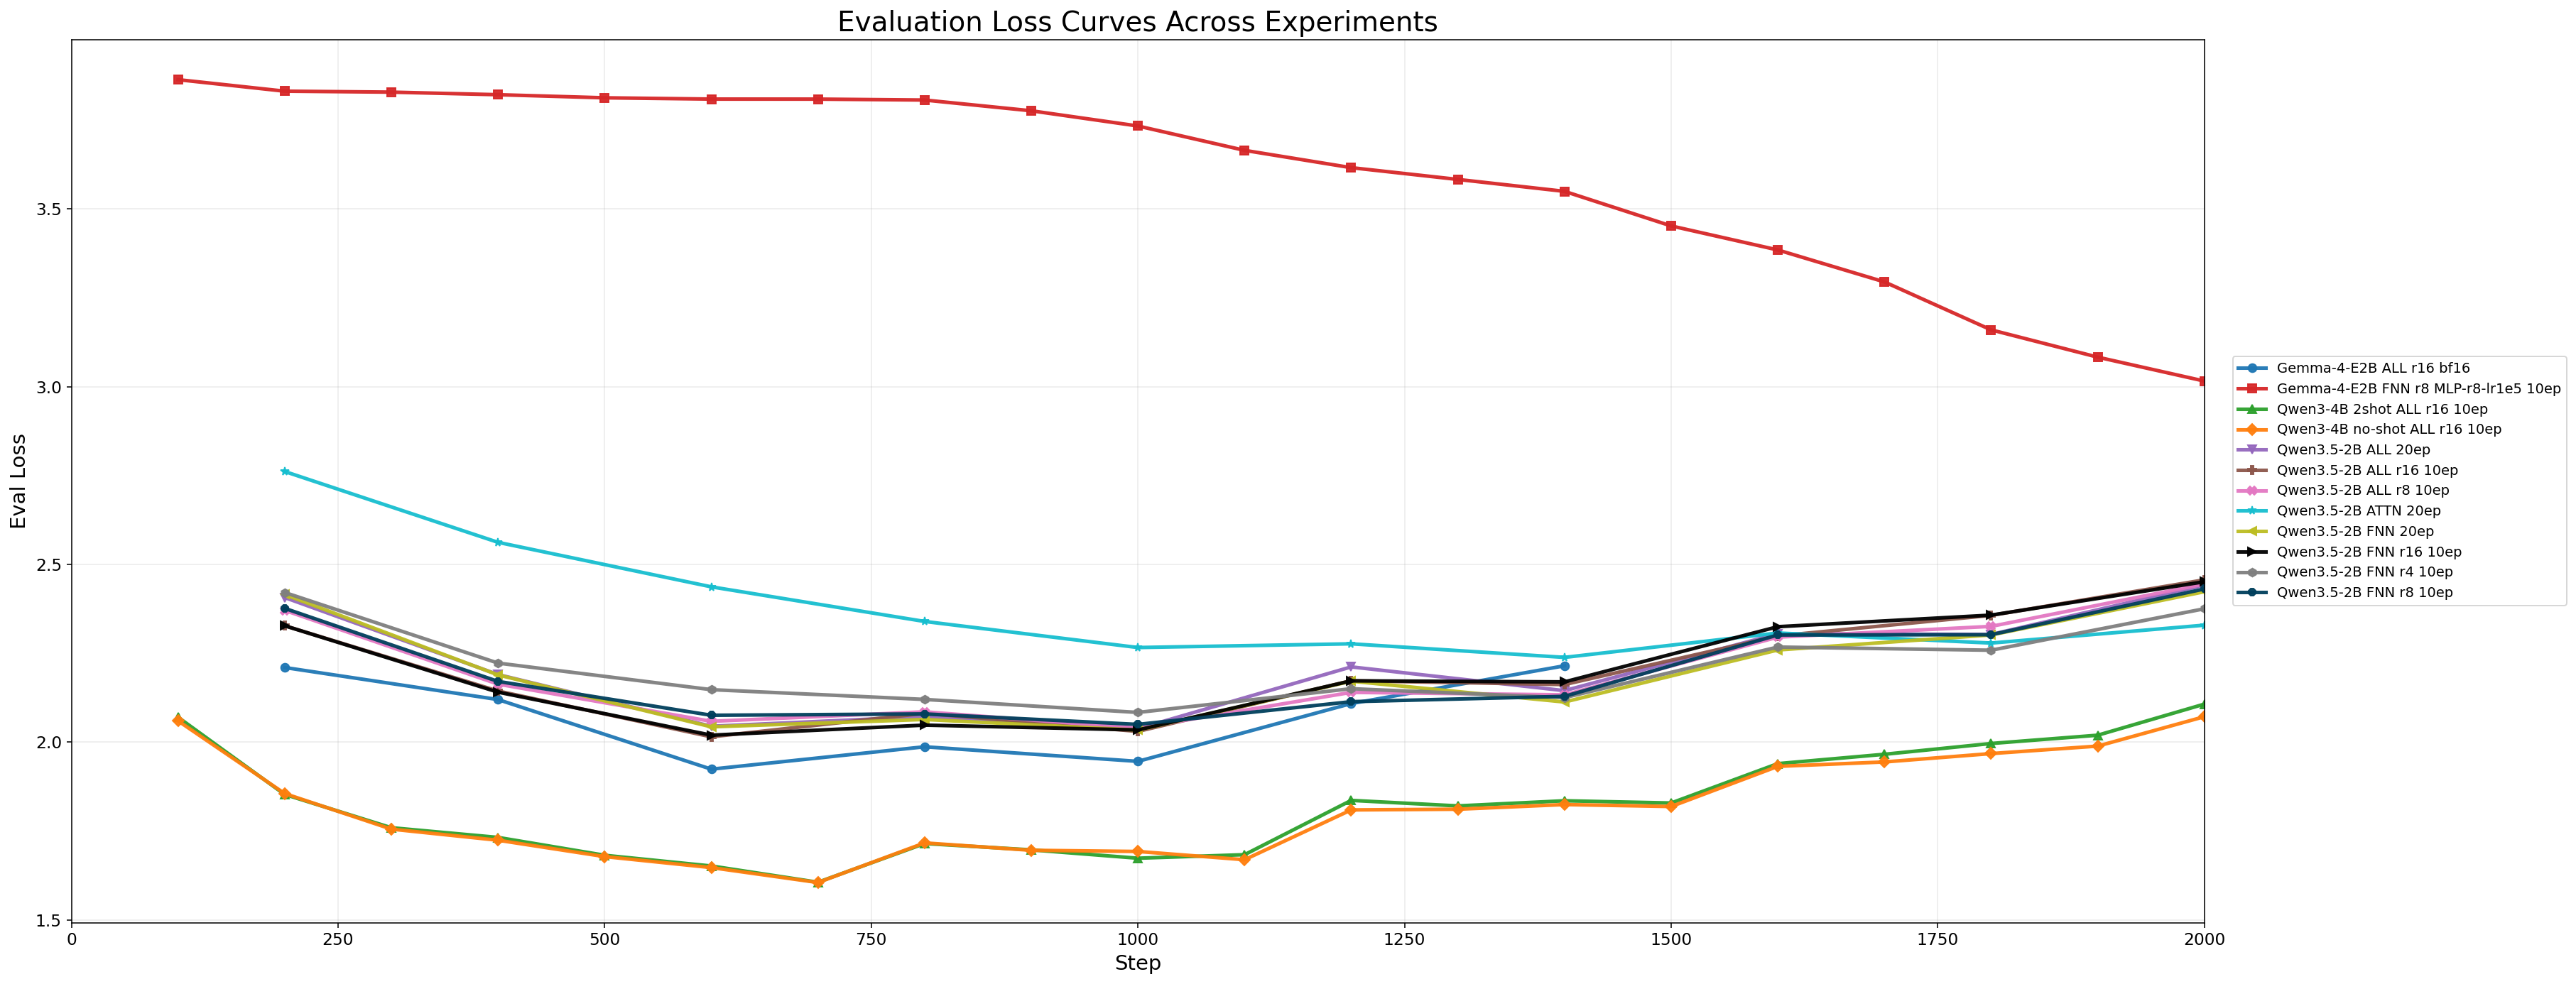

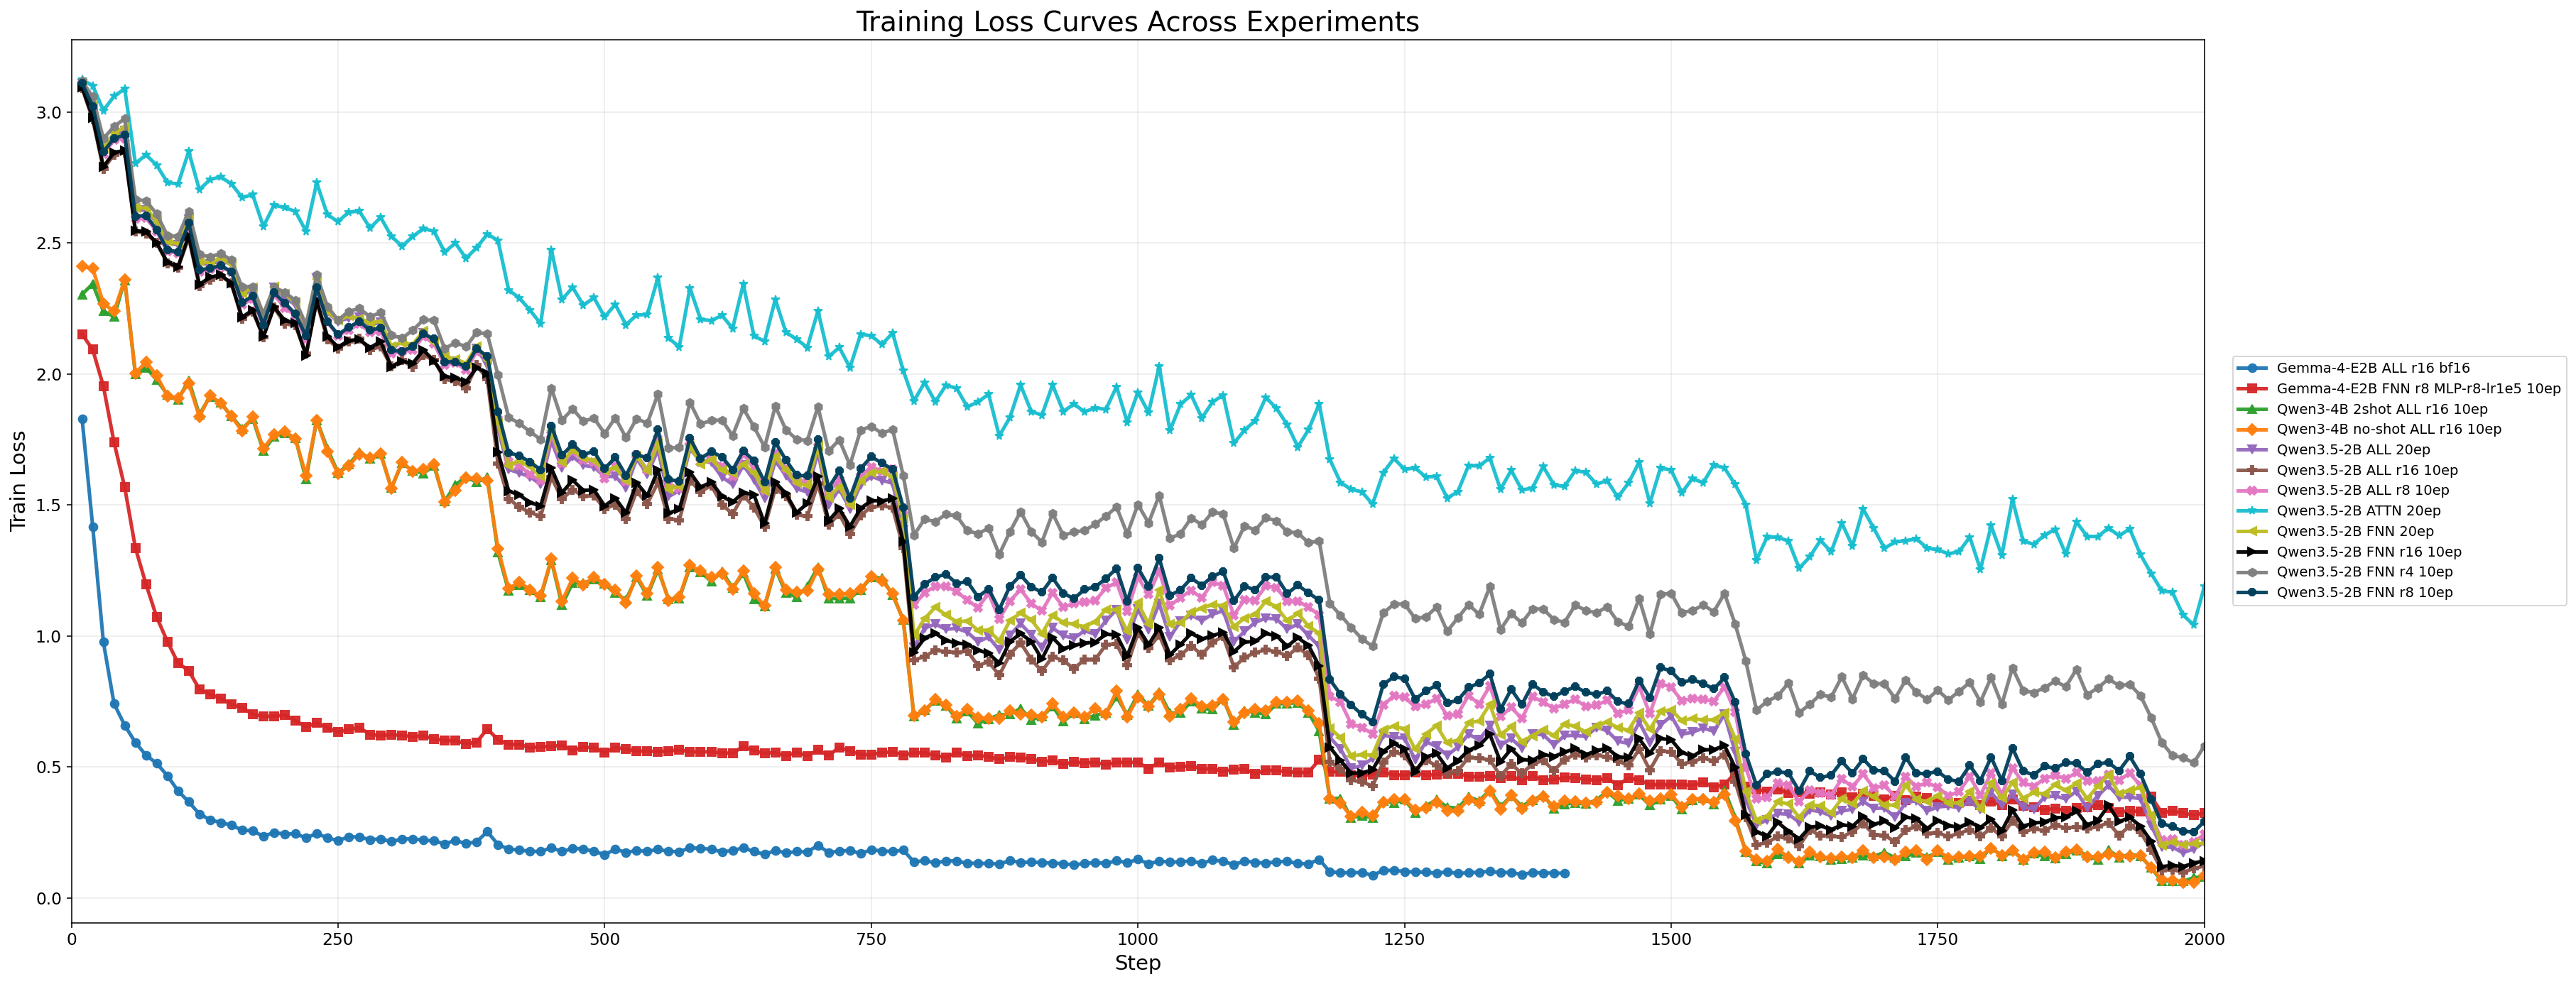

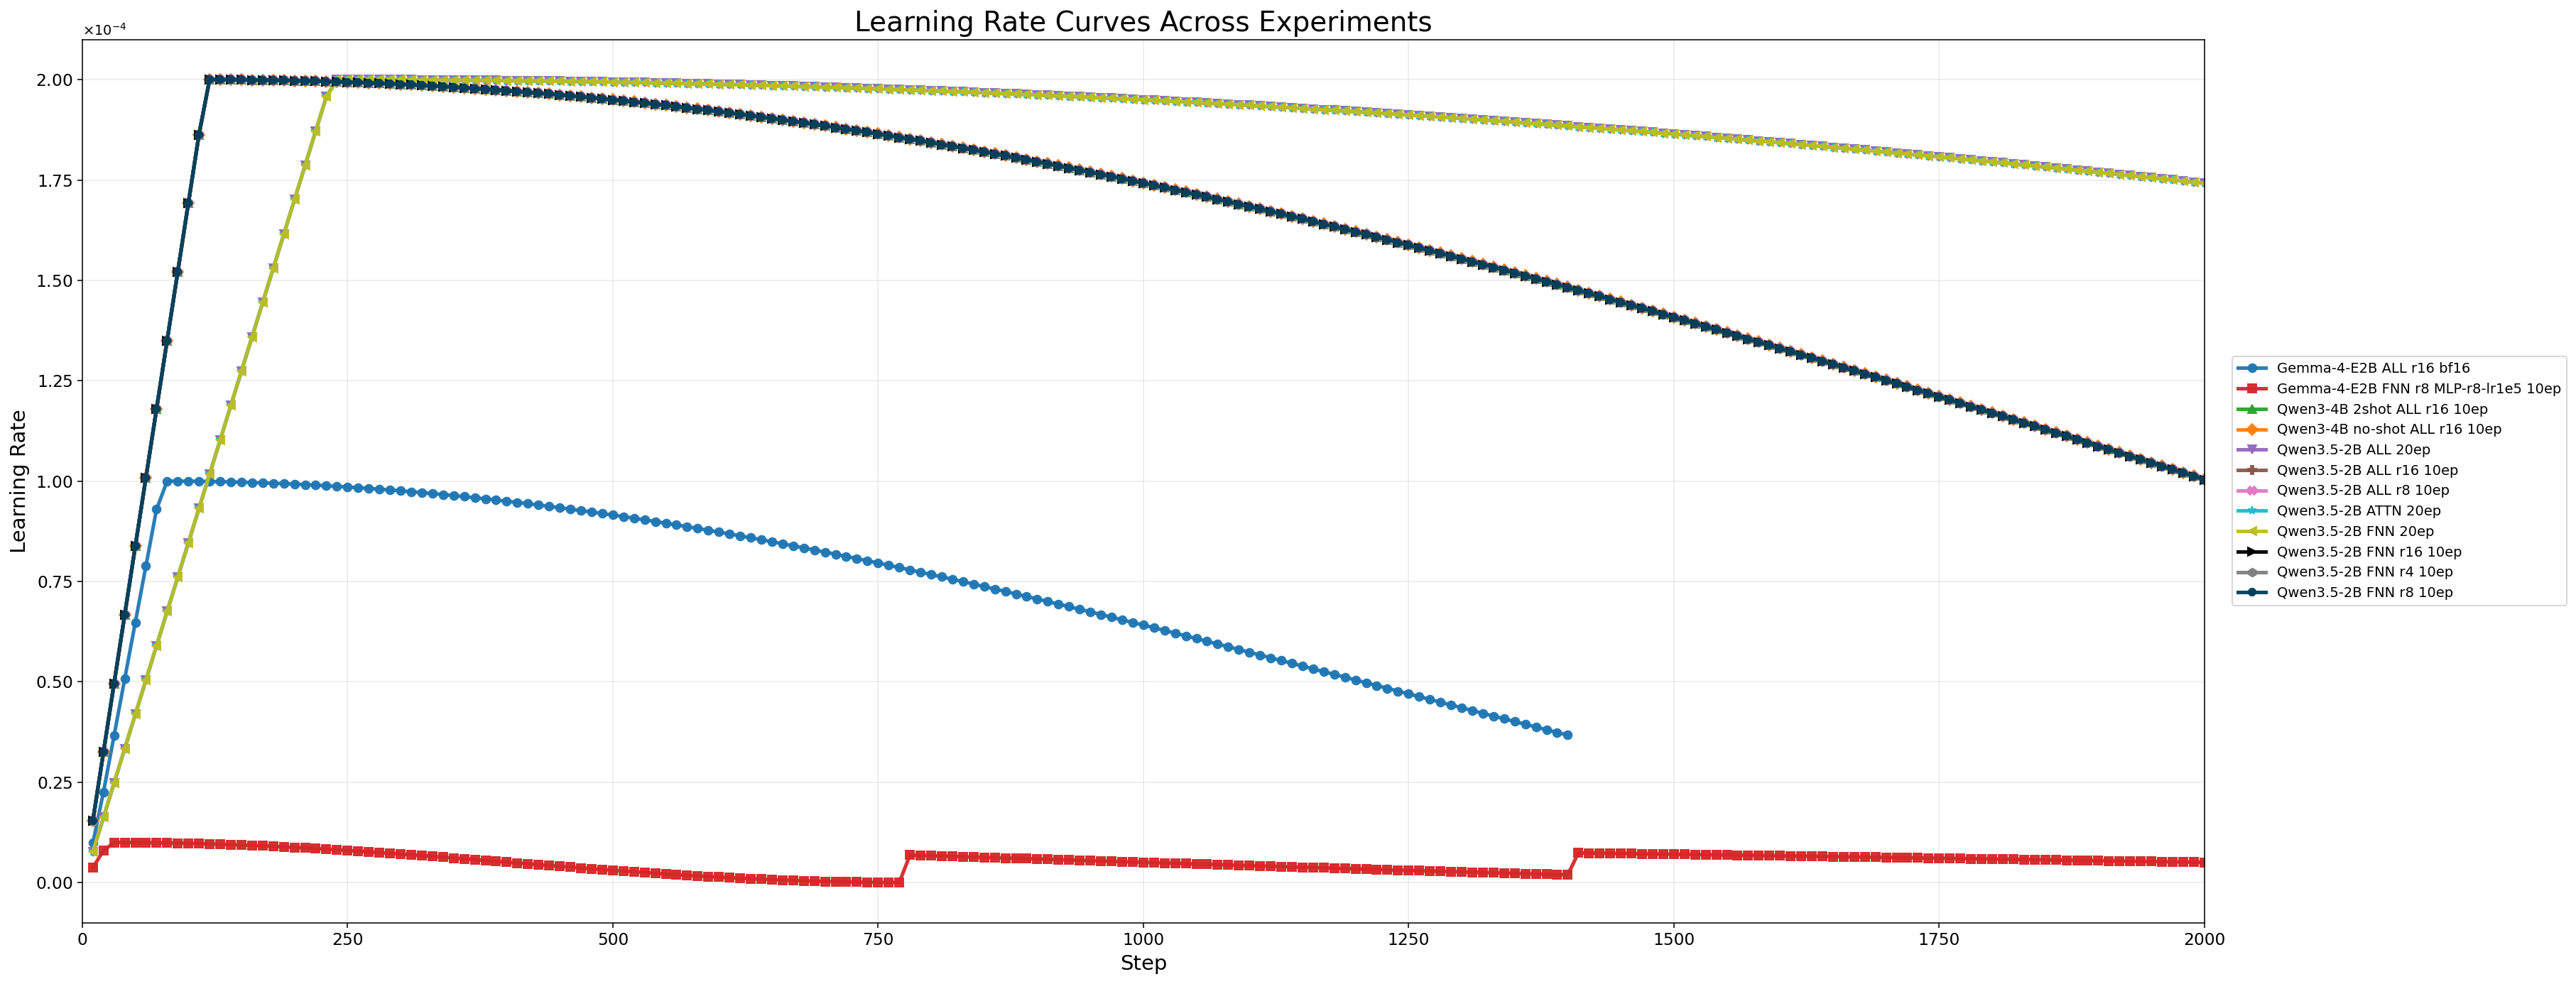


Compact Learning Curve Summary:


,display_name,experiment,last_train_step,last_train_loss,best_eval_step,best_eval_loss,last_eval_step,last_eval_loss,last_lr_step,last_learning_rate
0,Qwen3-4B no-shot ALL r16 10ep,qwen3_4b_alexandria_eg_only_context3_noshot_al...,2000,0.086234,700,1.605091,2000,2.071752,2000,0.000100
1,Qwen3-4B 2shot ALL r16 10ep,qwen3_4b_alexandria_eg_only_context3_complete2...,2000,0.080355,700,1.605848,2000,2.107162,2000,0.000100
2,Gemma-4-E2B ALL r16 bf16,gemma4_e2b_it_alexandria_eg_only_context3_all_...,1400,0.093597,600,1.924034,1400,2.214934,1400,0.000037
3,Qwen3.5-2B ALL r16 10ep,qwen35_2b_alexandria_eg_only_context3_all_grou...,2000,0.121548,600,2.015077,2000,2.456787,2000,0.000100
4,Qwen3.5-2B FNN r16 10ep,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,2000,0.141033,600,2.019729,2000,2.451434,2000,0.000100
5,Qwen3.5-2B FNN 20ep,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,2000,0.207485,1000,2.034061,2000,2.423385,2000,0.000174
6,Qwen3.5-2B ALL 20ep,qwen35_2b_alexandria_eg_only_context3_all_grou...,2000,0.212015,1000,2.037946,2000,2.442135,2000,0.000174
7,Qwen3.5-2B ALL r8 10ep,qwen35_2b_alexandria_eg_only_context3_all_grou...,2000,0.242138,1000,2.039442,2000,2.445004,2000,0.000100
8,Qwen3.5-2B FNN r8 10ep,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,2000,0.291910,1000,2.050013,2000,2.431273,2000,0.000100
9,Qwen3.5-2B FNN r4 10ep,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,2000,0.580142,1000,2.083685,2000,2.375417,2000,0.000100


In [23]:
# ============================================================
# Learning Curve Comparison Cell — Clean Final Version
# Reads trainer_state.json files from RUNS_DIR and plots only:
# 1. Evaluation Loss Curves Across Experiments
# 2. Training Loss Curves Across Experiments
# 3. Learning Rate Curves Across Experiments
#
# Rules:
# - Remove resume-safe curve
# - Stop all curves at step <= 2000
# - Eval curve uses 100-step grid, fallback 200-step grid
# - Larger readable plots
# - Distinct colors, markers, line styles
# ============================================================

import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

if "RUNS_DIR" not in globals():
    raise RuntimeError("RUNS_DIR is not defined.")

RUNS_DIR = Path(RUNS_DIR)

print("Searching trainer states under:")
print(RUNS_DIR)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

MAX_STEP_TO_PLOT = 2000

EVAL_PRIMARY_GRID = 100
EVAL_FALLBACK_GRID = 200
MIN_POINTS_FOR_GRID = 2

FIGSIZE = (26, 10)
DPI = 140

DROP_EXPERIMENTS_CONTAINING = [
    "resume_safe",
    "resume safe",
]

# ------------------------------------------------------------
# Find trainer_state.json files
# ------------------------------------------------------------

state_paths = list(RUNS_DIR.rglob("trainer_state.json"))

if not state_paths:
    raise FileNotFoundError(f"No trainer_state.json files found under {RUNS_DIR}")

print(f"Found {len(state_paths)} trainer_state.json files.")

# ------------------------------------------------------------
# Experiment name helper
# ------------------------------------------------------------

def get_experiment_name_from_state_path(path):
    path = Path(path)

    if path.parent.name.startswith("checkpoint-"):
        return path.parent.parent.name

    return path.parent.name

# ------------------------------------------------------------
# Load best trainer_state per experiment
# ------------------------------------------------------------

experiment_states = {}

for state_path in state_paths:
    exp_name = get_experiment_name_from_state_path(state_path)

    exp_name_lower = exp_name.lower()

    if any(drop_key.lower() in exp_name_lower for drop_key in DROP_EXPERIMENTS_CONTAINING):
        continue

    try:
        with open(state_path, "r", encoding="utf-8") as f:
            state = json.load(f)
    except Exception as e:
        print(f"Skipping unreadable state: {state_path} | {repr(e)}")
        continue

    log_history = state.get("log_history", [])
    max_step = max([x.get("step", -1) for x in log_history], default=-1)
    n_logs = len(log_history)
    mtime = state_path.stat().st_mtime

    candidate = {
        "experiment": exp_name,
        "state_path": state_path,
        "state": state,
        "max_step": max_step,
        "n_logs": n_logs,
        "mtime": mtime,
    }

    if exp_name not in experiment_states:
        experiment_states[exp_name] = candidate
    else:
        old = experiment_states[exp_name]

        better = (
            candidate["max_step"] > old["max_step"]
            or (
                candidate["max_step"] == old["max_step"]
                and candidate["n_logs"] > old["n_logs"]
            )
            or (
                candidate["max_step"] == old["max_step"]
                and candidate["n_logs"] == old["n_logs"]
                and candidate["mtime"] > old["mtime"]
            )
        )

        if better:
            experiment_states[exp_name] = candidate

print(f"Using {len(experiment_states)} experiment trainer states after filtering.")

# ------------------------------------------------------------
# Short labels
# ------------------------------------------------------------

def make_short_label(exp_name):
    name = exp_name

    replacements = {
        "alexandria_eg_only_context3_": "",
        "alexandria_eg_only_": "",
        "qwen35_2b_": "Qwen3.5-2B ",
        "qwen3_4b_": "Qwen3-4B ",
        "gemma4_e2b_it_": "Gemma-4-E2B ",
        "all_group": "ALL",
        "fnn_group": "FNN",
        "attn": "ATTN",
        "complete2shot": "2shot",
        "noshot": "no-shot",
        "10epochs": "10ep",
        "20epochs": "20ep",
        "r16": "r16",
        "r8": "r8",
        "_v1": "",
        "_v2": "",
        "_bf16_16bit": " bf16",
        "_prompt_nat_eg_mlp_r8_lr1e5": " MLP-r8-lr1e5",
    }

    for old, new in replacements.items():
        name = name.replace(old, new)

    name = name.replace("_", " ")
    name = " ".join(name.split())

    return name

# ------------------------------------------------------------
# Convert trainer_state log_history to DataFrame
# ------------------------------------------------------------

rows = []

for exp_name, item in experiment_states.items():
    state = item["state"]
    state_path = item["state_path"]
    log_history = state.get("log_history", [])

    best_metric = state.get("best_metric", None)
    best_model_checkpoint = state.get("best_model_checkpoint", None)

    for log in log_history:
        step = log.get("step", None)

        if step is None:
            continue

        step = int(step)

        if step > MAX_STEP_TO_PLOT:
            continue

        base = {
            "experiment": exp_name,
            "display_name": make_short_label(exp_name),
            "step": step,
            "epoch": log.get("epoch", None),
            "state_path": str(state_path),
            "best_metric": best_metric,
            "best_model_checkpoint": best_model_checkpoint,
        }

        if "loss" in log:
            r = base.copy()
            r["metric"] = "train_loss"
            r["value"] = float(log["loss"])
            rows.append(r)

        if "eval_loss" in log:
            r = base.copy()
            r["metric"] = "eval_loss"
            r["value"] = float(log["eval_loss"])
            rows.append(r)

        if "learning_rate" in log:
            r = base.copy()
            r["metric"] = "learning_rate"
            r["value"] = float(log["learning_rate"])
            rows.append(r)

curve_df = pd.DataFrame(rows)

if curve_df.empty:
    raise RuntimeError("No metrics were found in trainer_state log_history after filtering.")

curve_df = curve_df.sort_values(["display_name", "metric", "step"]).reset_index(drop=True)

print("\nLoaded curve rows:", len(curve_df))
print("Experiments found:", curve_df["experiment"].nunique())
print("Max plotted step:", MAX_STEP_TO_PLOT)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary_df = (
    curve_df.groupby(["display_name", "metric"])
    .agg(
        num_points=("value", "count"),
        first_step=("step", "min"),
        last_step=("step", "max"),
        min_value=("value", "min"),
        last_value=("value", "last"),
    )
    .reset_index()
)

display(summary_df)

# ------------------------------------------------------------
# Distinct colors, markers, line styles
# ------------------------------------------------------------

display_names_sorted = sorted(curve_df["display_name"].unique().tolist())
n_exp = len(display_names_sorted)

distinct_colors = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#ff7f0e",  # orange
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#17becf",  # cyan
    "#bcbd22",  # olive
    "#000000",  # black
    "#7f7f7f",  # gray
    "#003f5c",  # deep blue
    "#ffa600",  # yellow-orange
    "#665191",  # violet
    "#a05195",  # purple-magenta
    "#f95d6a",  # coral
    "#2f4b7c",  # navy
    "#00a087",  # teal
    "#b22222",  # firebrick
    "#228b22",  # forest green
]

if n_exp > len(distinct_colors):
    extra_colors = [
        mcolors.to_hex(plt.cm.hsv(i / max(1, n_exp)))
        for i in range(n_exp)
    ]
    distinct_colors.extend(extra_colors)

marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "8", "p"]
line_style_cycle = ["-", "--", "-.", ":"]

color_map = {
    name: distinct_colors[i % len(distinct_colors)]
    for i, name in enumerate(display_names_sorted)
}

marker_map = {
    name: marker_cycle[i % len(marker_cycle)]
    for i, name in enumerate(display_names_sorted)
}

linestyle_map = {
    name: line_style_cycle[(i // len(marker_cycle)) % len(line_style_cycle)]
    for i, name in enumerate(display_names_sorted)
}

color_table = pd.DataFrame({
    "display_name": display_names_sorted,
    "color": [color_map[x] for x in display_names_sorted],
    "marker": [marker_map[x] for x in display_names_sorted],
    "linestyle": [linestyle_map[x] for x in display_names_sorted],
})

print("\nColor / Marker Map:")
display(color_table)

# ------------------------------------------------------------
# Eval curve filtering
# ------------------------------------------------------------

def filter_eval_points_for_grid(exp_df):
    exp_df = exp_df.sort_values("step").copy()

    grid_100 = exp_df[exp_df["step"] % EVAL_PRIMARY_GRID == 0].copy()

    if len(grid_100) >= MIN_POINTS_FOR_GRID:
        grid_100["eval_grid_used"] = EVAL_PRIMARY_GRID
        return grid_100

    grid_200 = exp_df[exp_df["step"] % EVAL_FALLBACK_GRID == 0].copy()

    if len(grid_200) >= MIN_POINTS_FOR_GRID:
        grid_200["eval_grid_used"] = EVAL_FALLBACK_GRID
        return grid_200

    exp_df["eval_grid_used"] = "all_available"
    return exp_df

eval_curve_parts = []

for display_name, exp_df in curve_df[curve_df["metric"] == "eval_loss"].groupby("display_name"):
    eval_curve_parts.append(filter_eval_points_for_grid(exp_df))

eval_curve_df = pd.concat(eval_curve_parts, ignore_index=True) if eval_curve_parts else pd.DataFrame()

if not eval_curve_df.empty:
    print("\nEval curve grid used:")
    display(
        eval_curve_df.groupby("display_name")
        .agg(
            eval_grid_used=("eval_grid_used", "first"),
            num_eval_points=("value", "count"),
            first_eval_step=("step", "min"),
            last_eval_step=("step", "max"),
            best_eval_loss=("value", "min"),
        )
        .reset_index()
        .sort_values("best_eval_loss")
    )

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------

def plot_metric(metric_name, title, ylabel, data_df=None, scientific_y=False):
    if data_df is None:
        tmp = curve_df[curve_df["metric"] == metric_name].copy()
    else:
        tmp = data_df[data_df["metric"] == metric_name].copy()

    if tmp.empty:
        print(f"No data found for {metric_name}.")
        return

    plt.figure(figsize=FIGSIZE, dpi=DPI)

    for display_name, exp_df in tmp.groupby("display_name"):
        exp_df = exp_df.sort_values("step")

        plt.plot(
            exp_df["step"],
            exp_df["value"],
            marker=marker_map[display_name],
            linestyle=linestyle_map[display_name],
            linewidth=2.6,
            markersize=6,
            label=display_name,
            color=color_map[display_name],
            alpha=0.95,
        )

    plt.title(title, fontsize=20)
    plt.xlabel("Step", fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.xlim(0, MAX_STEP_TO_PLOT)

    if scientific_y:
        ax = plt.gca()
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((-3, 3))
        ax.yaxis.set_major_formatter(formatter)

    plt.grid(True, alpha=0.25)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(
        fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
        ncol=1,
    )

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Only the requested 3 plots
# ------------------------------------------------------------

plot_metric(
    metric_name="eval_loss",
    title="Evaluation Loss Curves Across Experiments",
    ylabel="Eval Loss",
    data_df=eval_curve_df,
)

plot_metric(
    metric_name="train_loss",
    title="Training Loss Curves Across Experiments",
    ylabel="Train Loss",
)

plot_metric(
    metric_name="learning_rate",
    title="Learning Rate Curves Across Experiments",
    ylabel="Learning Rate",
    scientific_y=True,
)

# ------------------------------------------------------------
# Compact summary
# ------------------------------------------------------------

compact_rows = []

for display_name in display_names_sorted:
    exp_train = curve_df[
        (curve_df["display_name"] == display_name)
        & (curve_df["metric"] == "train_loss")
    ].sort_values("step")

    exp_eval = curve_df[
        (curve_df["display_name"] == display_name)
        & (curve_df["metric"] == "eval_loss")
    ].sort_values("step")

    exp_lr = curve_df[
        (curve_df["display_name"] == display_name)
        & (curve_df["metric"] == "learning_rate")
    ].sort_values("step")

    compact_rows.append({
        "display_name": display_name,
        "experiment": (
            exp_train["experiment"].iloc[0]
            if len(exp_train)
            else exp_eval["experiment"].iloc[0]
            if len(exp_eval)
            else ""
        ),
        "last_train_step": int(exp_train["step"].max()) if len(exp_train) else None,
        "last_train_loss": float(exp_train.iloc[-1]["value"]) if len(exp_train) else None,
        "best_eval_step": int(exp_eval.loc[exp_eval["value"].idxmin(), "step"]) if len(exp_eval) else None,
        "best_eval_loss": float(exp_eval["value"].min()) if len(exp_eval) else None,
        "last_eval_step": int(exp_eval["step"].max()) if len(exp_eval) else None,
        "last_eval_loss": float(exp_eval.iloc[-1]["value"]) if len(exp_eval) else None,
        "last_lr_step": int(exp_lr["step"].max()) if len(exp_lr) else None,
        "last_learning_rate": float(exp_lr.iloc[-1]["value"]) if len(exp_lr) else None,
    })

compact_summary_df = pd.DataFrame(compact_rows).sort_values(
    "best_eval_loss",
    ascending=True,
    na_position="last",
).reset_index(drop=True)

print("\nCompact Learning Curve Summary:")
display(compact_summary_df)